In [2]:
import spatialdata as sd
import datashader as ds
import shapely as sp
import pandas as pd
import colorcet

import spatialdata_plot

import dask

import json
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

/mnt/hdd1/leiden-cellseg/task_spatial_segmentation/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [87]:
sdata = sd.read_zarr("../data/datasets/gt_annotated_data/WTA_Preview_FFPE_Breast_Cancer_Aligned.zarr")
sdata

SpatialData object, with associated Zarr store: /mnt/hdd1/leiden-cellseg/task_spatial_segmentation/data/datasets/gt_annotated_data/WTA_Preview_FFPE_Breast_Cancer_Aligned.zarr
├── Images
│     ├── 'hne_aligned': DataArray[cyx] (90368, 3, 47337)
│     └── 'morphology_focus': DataTree[cyx] (4, 28048, 46543), (4, 14024, 23271), (4, 7012, 11635), (4, 3506, 5817), (4, 1753, 2908)
├── Labels
│     ├── 'cell_labels': DataTree[yx] (28048, 46543), (14024, 23271), (7012, 11635), (3506, 5817), (1753, 2908)
│     └── 'nucleus_labels': DataTree[yx] (28048, 46543), (14024, 23271), (7012, 11635), (3506, 5817), (1753, 2908)
├── Points
│     └── 'transcripts': DataFrame with shape: (<Delayed>, 13) (3D points)
├── Shapes
│     ├── 'cell_boundaries': GeoDataFrame shape: (170057, 1) (2D shapes)
│     └── 'nucleus_boundaries': GeoDataFrame shape: (169293, 2) (2D shapes)
└── Tables
      └── 'table': AnnData (170057, 18028)
with coordinate systems:
    ▸ 'global', with elements:
        hne_aligned (Images),

In [6]:
geojson = {"features":[{"geometry":{"coordinates":[[[43764.42734883407,18022.142731517404],[47218.18930720695,18061.4509625142],[47260.136658524316,14375.806440729488],[43806.37470015144,14336.498209732694],[43764.42734883407,18022.142731517404]]],"plane":{"z":6},"type":"Polygon"},"properties":{"classification":{"color":[194,194,194],"name":"Unclassified"},"color":[194,194,194],"name":"Annotation","objectType":"annotation"},"type":"Feature"}],"type":"FeatureCollection"}

poly = sp.geometry.shape(geojson['features'][0]['geometry'])
bb_xmin, bb_ymin, bb_xmax, bb_ymax = poly.bounds

poly.bounds

(43764.42734883407, 14336.498209732694, 47260.136658524316, 18061.4509625142)

In [5]:
cropped_sdata = sdata.query.bounding_box(
    axes=["x", "y"],
    min_coordinate=[bb_xmin, bb_ymin],
    max_coordinate=[bb_xmax, bb_ymax],
    target_coordinate_system="global",
)

/home/ubuntu/.local/share/uv/python/cpython-3.12.13-linux-x86_64-gnu/lib/python3.12/functools.py:912: UserWarning: The object has `points` element. Depending on the number of points, querying MAY suffer from performance issues. Please consider filtering the object before calling this function by calling the `subset()` method of `SpatialData`.
  return dispatch(args[0].__class__)(*args, **kw)


In [6]:
cropped_sdata

SpatialData object
├── Images
│     └── 'morphology_focus': DataTree[cyx] (4, 3725, 2779), (4, 1863, 1389), (4, 931, 695), (4, 466, 347), (4, 233, 174)
├── Labels
│     ├── 'cell_labels': DataTree[yx] (3725, 2779), (1863, 1389), (931, 695), (466, 347), (233, 174)
│     └── 'nucleus_labels': DataTree[yx] (3725, 2779), (1863, 1389), (931, 695), (466, 347), (233, 174)
├── Points
│     └── 'transcripts': DataFrame with shape: (<Delayed>, 13) (3D points)
├── Shapes
│     ├── 'cell_boundaries': GeoDataFrame shape: (1975, 1) (2D shapes)
│     └── 'nucleus_boundaries': GeoDataFrame shape: (1961, 2) (2D shapes)
└── Tables
      └── 'table': AnnData (1973, 18028)
with coordinate systems:
    ▸ 'global', with elements:
        morphology_focus (Images), cell_labels (Labels), nucleus_labels (Labels), transcripts (Points), cell_boundaries (Shapes), nucleus_boundaries (Shapes)

In [7]:
cropped_sdata.write("/mnt/hdd1/leiden-cellseg/task_spatial_segmentation/data/datasets/gt_annotated_data/WTA_Preview_FFPE_Breast_Cancer_Aligned_subset.zarr")

/mnt/hdd1/leiden-cellseg/task_spatial_segmentation/.venv/lib/python3.12/site-packages/dask/utils.py:782: UserWarning: Could not serialize pd.DataFrame.attrs: Object of type Scale is not JSON serializable, defaulting to empty attributes.
  return meth(arg, *args, **kwargs)
/mnt/hdd1/leiden-cellseg/task_spatial_segmentation/.venv/lib/python3.12/site-packages/dask/dataframe/io/parquet/arrow.py:824: UserWarning: Could not serialize pd.DataFrame.attrs: Object of type Scale is not JSON serializable, defaulting to empty attributes.
  t = cls._pandas_to_arrow_table(df, preserve_index=preserve_index, schema=schema)
/home/ubuntu/.local/share/uv/python/cpython-3.12.13-linux-x86_64-gnu/lib/python3.12/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/home/ubuntu/.local/share/uv/python/cpython-3.12.13-linux-x86_64-gnu/lib/python3.12/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor rel

In [10]:
cropped_sdata

SpatialData object, with associated Zarr store: /mnt/hdd1/leiden-cellseg/task_spatial_segmentation/data/datasets/gt_annotated_data/WTA_Preview_FFPE_Breast_Cancer_Aligned_subset.zarr
├── Images
│     └── 'morphology_focus': DataTree[cyx] (4, 3725, 2779), (4, 1863, 1389), (4, 931, 695), (4, 466, 347), (4, 233, 174)
├── Labels
│     ├── 'cell_labels': DataTree[yx] (3725, 2779), (1863, 1389), (931, 695), (466, 347), (233, 174)
│     └── 'nucleus_labels': DataTree[yx] (3725, 2779), (1863, 1389), (931, 695), (466, 347), (233, 174)
├── Points
│     └── 'transcripts': DataFrame with shape: (<Delayed>, 13) (3D points)
├── Shapes
│     ├── 'cell_boundaries': GeoDataFrame shape: (1975, 1) (2D shapes)
│     └── 'nucleus_boundaries': GeoDataFrame shape: (1961, 2) (2D shapes)
└── Tables
      └── 'table': AnnData (1973, 18028)
with coordinate systems:
    ▸ 'global', with elements:
        morphology_focus (Images), cell_labels (Labels), nucleus_labels (Labels), transcripts (Points), cell_boundaries

In [91]:
cropped_sdata = sd.read_zarr("/mnt/hdd1/leiden-cellseg/task_spatial_segmentation/data/datasets/gt_annotated_data/WTA_Preview_FFPE_Breast_Cancer_Aligned_subset.zarr")
cropped_sdata

SpatialData object, with associated Zarr store: /mnt/hdd1/leiden-cellseg/task_spatial_segmentation/data/datasets/gt_annotated_data/WTA_Preview_FFPE_Breast_Cancer_Aligned_subset.zarr
├── Images
│     └── 'morphology_focus': DataTree[cyx] (4, 3725, 2779), (4, 1863, 1389), (4, 931, 695), (4, 466, 347), (4, 233, 174)
├── Labels
│     ├── 'cell_labels': DataTree[yx] (3725, 2779), (1863, 1389), (931, 695), (466, 347), (233, 174)
│     └── 'nucleus_labels': DataTree[yx] (3725, 2779), (1863, 1389), (931, 695), (466, 347), (233, 174)
├── Points
│     └── 'transcripts': DataFrame with shape: (<Delayed>, 13) (3D points)
├── Shapes
│     ├── 'cell_boundaries': GeoDataFrame shape: (1975, 1) (2D shapes)
│     └── 'nucleus_boundaries': GeoDataFrame shape: (1961, 2) (2D shapes)
└── Tables
      └── 'table': AnnData (1973, 18028)
with coordinate systems:
    ▸ 'global', with elements:
        morphology_focus (Images), cell_labels (Labels), nucleus_labels (Labels), transcripts (Points), cell_boundaries

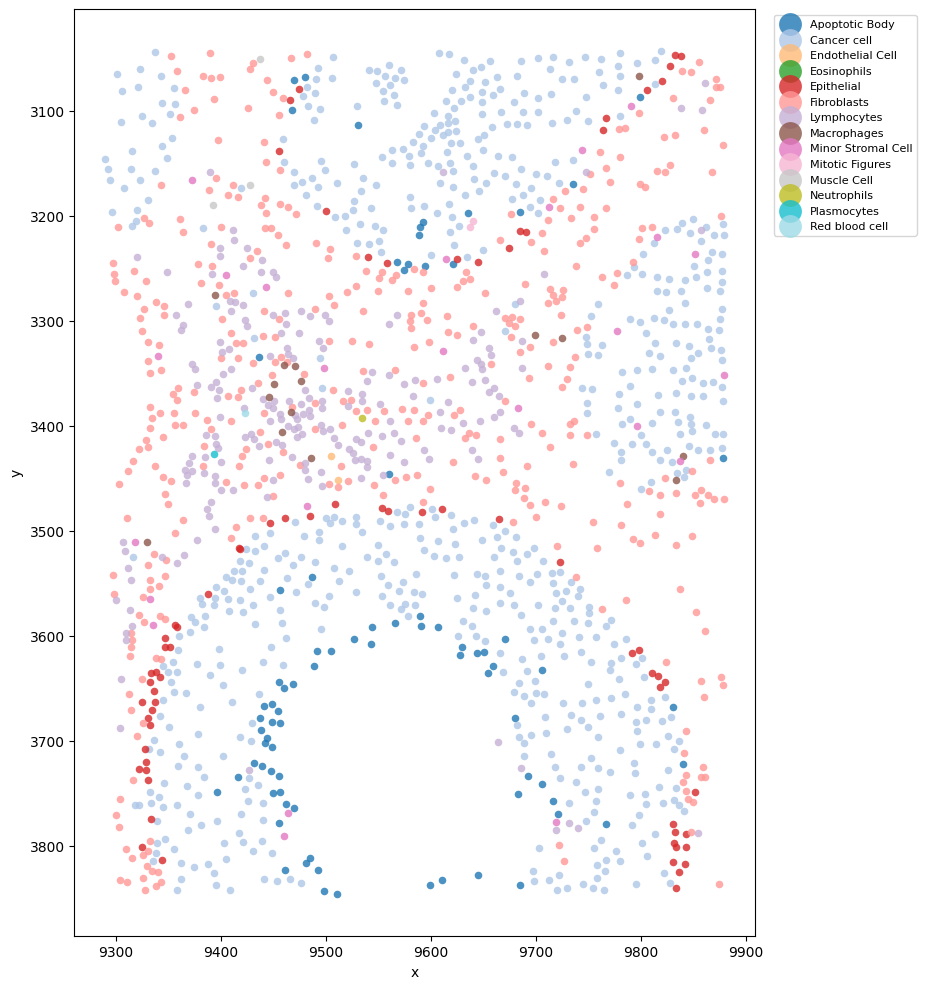

In [41]:
x_spatial = cropped_sdata.tables['table'].obsm['X_spatial']
classes = cropped_sdata['table'].obs['histoplus_cell_class']

# stable color per class
cats = pd.Categorical(classes)
cmap = plt.get_cmap('tab20', len(cats.categories))

fig, ax = plt.subplots(figsize=(10, 10))
for code, name in enumerate(cats.categories):
    m = cats.codes == code
    ax.scatter(x_spatial[m, 0], x_spatial[m, 1],
               s=30, c=[cmap(code)], label=name, alpha=0.8, linewidths=0)

ax.set_aspect('equal')
ax.invert_yaxis()                          # image-style y axis
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.legend(markerscale=3, fontsize=8, bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

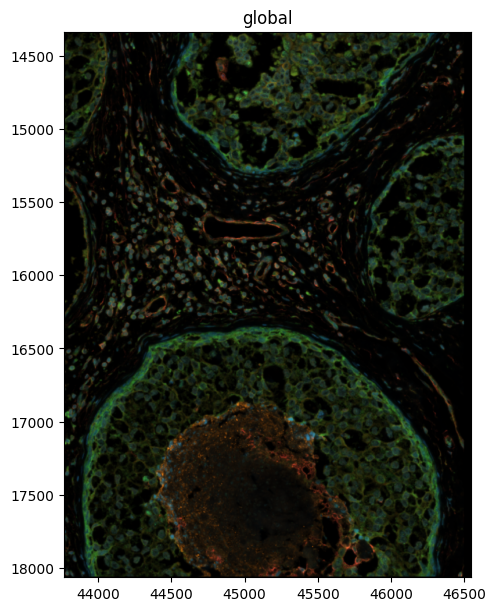

In [42]:
cropped_sdata.pl.render_images("morphology_focus").pl.show(figsize=(6, 6))

Try to fix the H&E

In [88]:
# --- 1. Fix axes + install correct affine on hne_aligned -----------------
img = sdata["hne_aligned"]
fixed_data = img.data.transpose(1, 2, 0)            # (x,c,y) -> (c,y,x)

he_aff = pd.read_csv("../data/datasets/gt_annotated_data/WTA_Preview_FFPE_Breast_Cancer_he_alignment.csv", header = None).values

sdata["hne_aligned"] = Image2DModel.parse(
    fixed_data,
    dims=("c", "y", "x"),
    transformations={"global": Affine(
        he_aff, input_axes=("x", "y"), output_axes=("x", "y"),
    )},
)


In [89]:
# --- 2. Crop the H&E to the geojson polygon ------------------------------
poly = sp.geometry.shape(geojson["features"][0]["geometry"])
bb_xmin, bb_ymin, bb_xmax, bb_ymax = poly.bounds

img = sdata["hne_aligned"]
aff = get_transformation(img, "global").to_affine_matrix(
    input_axes=("x", "y"), output_axes=("x", "y"),
)
inv = np.linalg.inv(aff)

corners = np.array([
    [bb_xmin, bb_ymin, 1],
    [bb_xmax, bb_ymin, 1],
    [bb_xmax, bb_ymax, 1],
    [bb_xmin, bb_ymax, 1],
]).T
px = inv @ corners                                   # rows: x_px, y_px, 1
nx, ny = img.sizes["x"], img.sizes["y"]
x0 = max(0, min(nx, int(np.floor(px[0].min()))))
x1 = max(0, min(nx, int(np.ceil (px[0].max()))))
y0 = max(0, min(ny, int(np.floor(px[1].min()))))
y1 = max(0, min(ny, int(np.ceil (px[1].max()))))
assert x0 < x1 and y0 < y1, "pixel bbox empty"

# slicing shifts pixel origin -> compose translation into affine
T = np.array([[1, 0, x0], [0, 1, y0], [0, 0, 1]], dtype=float)
hne_sliced = img.isel(y=slice(y0, y1), x=slice(x0, x1)).transpose("c", "y", "x")

hne_crop = Image2DModel.parse(
    hne_sliced.data,
    dims=("c", "y", "x"),
    transformations={"global": Affine(
        aff @ T, input_axes=("x", "y"), output_axes=("x", "y"),
    )},
)

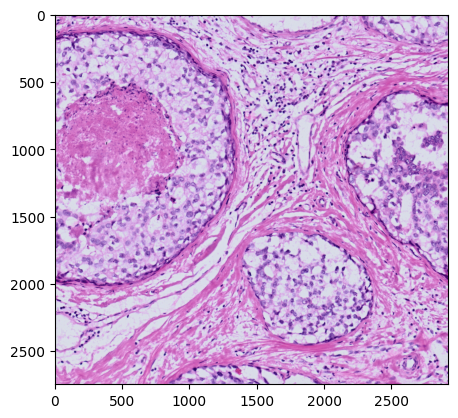

In [90]:
plt.imshow(hne_crop.values.transpose(1, 2, 0))

In [92]:
# attach the H&E crop and verify alignment
cropped_sdata["hne_aligned"] = hne_crop

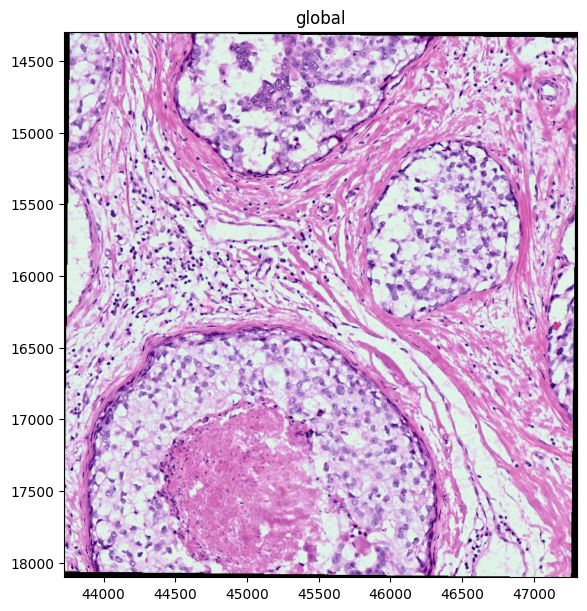

In [93]:
cropped_sdata.pl.render_images("hne_aligned").pl.show(figsize=(6, 6))

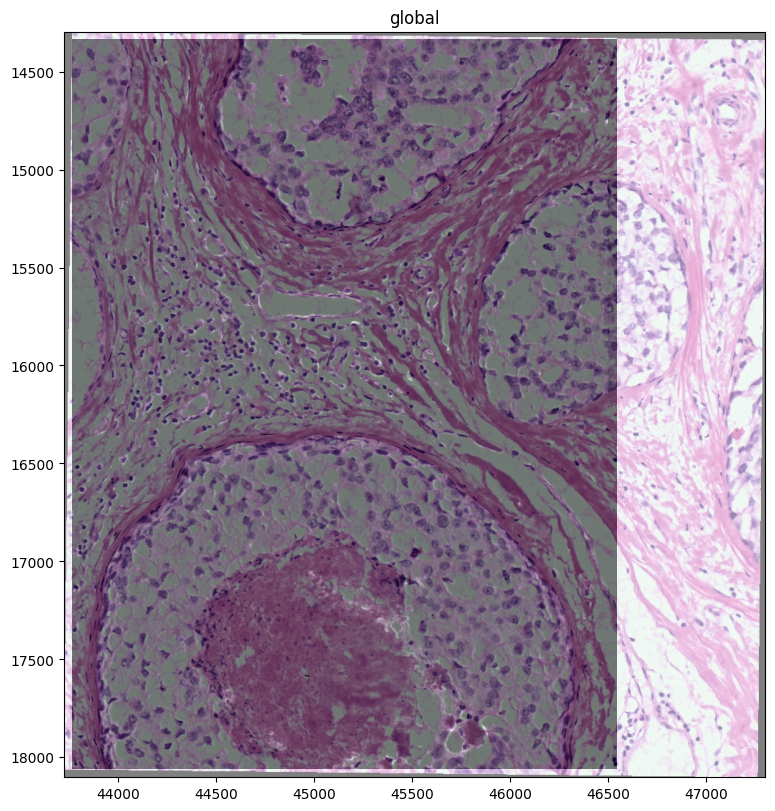

In [94]:
(cropped_sdata
    .pl.render_images("morphology_focus", cmap="gray")
    .pl.render_images("hne_aligned", alpha=0.5)
    .pl.show(figsize=(8, 8))
)

In [95]:
cropped_sdata.write_element("hne_aligned") 